# The available data #

In [26]:
from pathlib import Path
import pandas as pd
import xarray as xr

data_solar_energy = Path("Datasets/SARAH_3_SIS_20180101-20251010_daily.nc")
data_solar_production = Path("Datasets/Generation_2015-2024_hourly.csv")

pd_data_solar_energy = xr.open_dataset(data_solar_energy)
pd_data_solar_energy = pd_data_solar_energy.to_dataframe()

pd_data_solar_production = pd.read_csv(data_solar_production, sep=";")


### We have the daily average SIS (solar surface irradiance) in $\mathrm{W/m^2}$ in 0,05° × 0,05° steps from 2018 - 2025 (below, we show the average values for all years as examples). ###

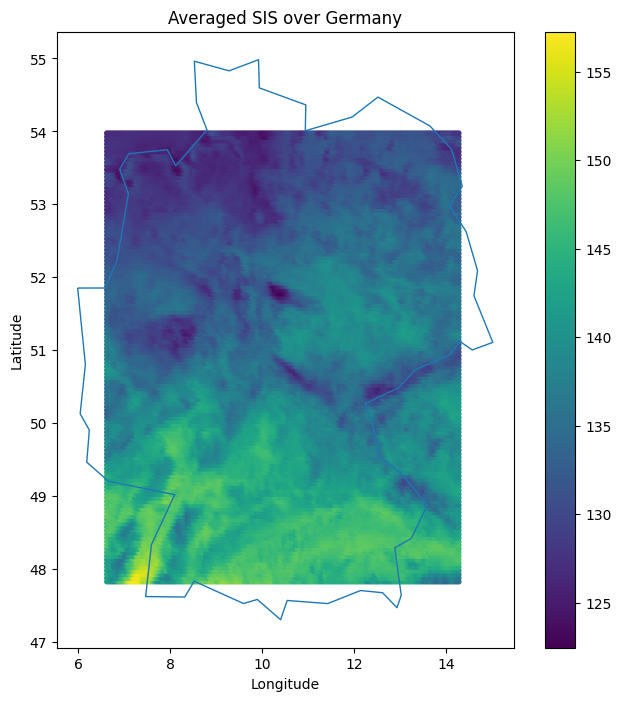

In [27]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

df_data_solar_energy_full = pd_data_solar_energy.reset_index()

# Average over time
mean_sis = df_data_solar_energy_full.groupby(["lat", "lon"], as_index=False)["SIS"].mean()

# GeoDataFrame
gdf = gpd.GeoDataFrame(mean_sis, geometry=gpd.points_from_xy(mean_sis["lon"], mean_sis["lat"]), crs="EPSG:4326")

# Coutry boundaries
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

germany = world[world["ADMIN"] == "Germany"]

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
germany.boundary.plot(ax=ax, linewidth=1)
gdf.plot(ax=ax, column="SIS", legend=True, markersize=10)

ax.set_title("Averaged SIS over Germany")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


### We have the hourly solar energy production (one value for the whole of Germany) from 2015 - 2024 ###

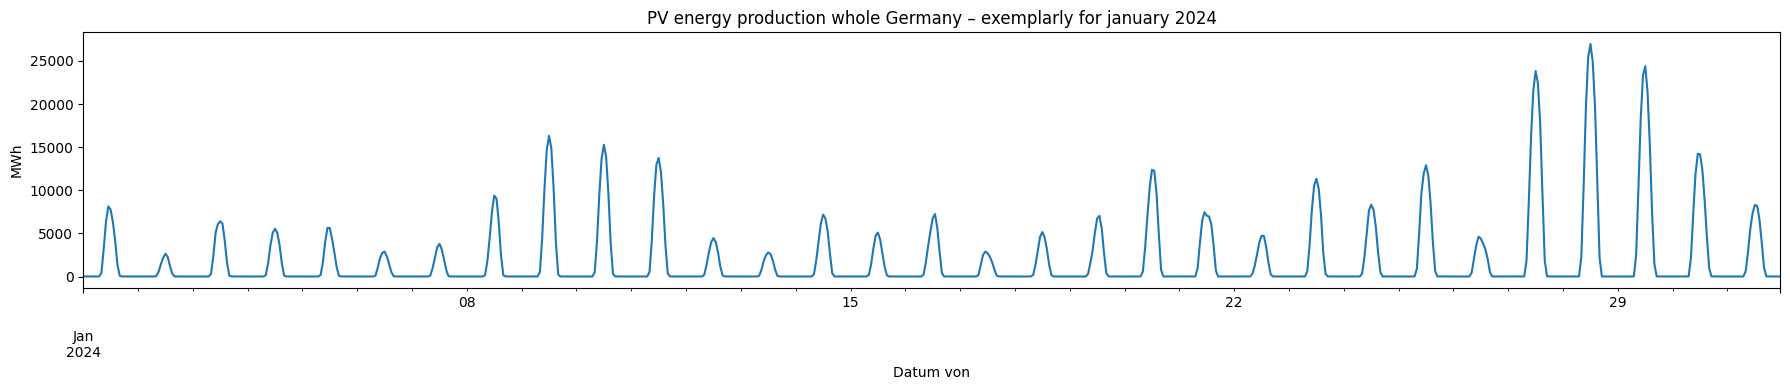

In [28]:
import numpy as np
pv_raw = pd_data_solar_production.copy()
pv_raw["Datum von"] = pd.to_datetime(pv_raw["Datum von"], format="%d.%m.%Y %H:%M")
pv_raw["PV_MWh"] = pv_raw["Photovoltaik [MWh] Berechnete Auflösungen"].astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)

pv_hourly = pv_raw.set_index("Datum von")["PV_MWh"]

plt.figure(figsize=(18, 4))
pv_hourly.loc["2024-01-01":"2024-01-31"].plot()
plt.ylabel("MWh")
plt.title("PV energy production whole Germany – exemplarly for january 2024")
plt.tight_layout()
plt.show()

### We have the actual distribution for the end of 2024, which we will ONLY compare with at the end and use to calibrate the scaling ###

<img src="photovoltaik-leistung-deutschland-karte.webp" width=300>

In [29]:
total_pv_MW = 99196 #taken out of the image as the sum of the production of all states
# This is the only information we use out of this image to have a more attractive visualization later on

# Goal: Determining this distribution of total installed capacity throughout Germany #

In [30]:
alphas_to_test = [0.1, 1.0, 10.0, 100.0, 1000, 10000, 100000, 1000000]

start_dates_to_test = [
    "2019-01-01",
    "2020-01-01",
    "2021-01-01",
    "2022-01-01",
    "2023-01-01",
    "2024-01-01",
]

# End date must not be modified
end_date   = "2024-12-31"

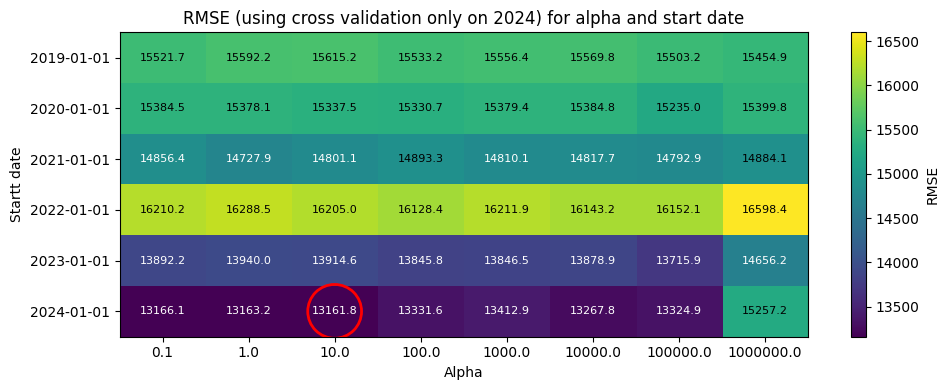

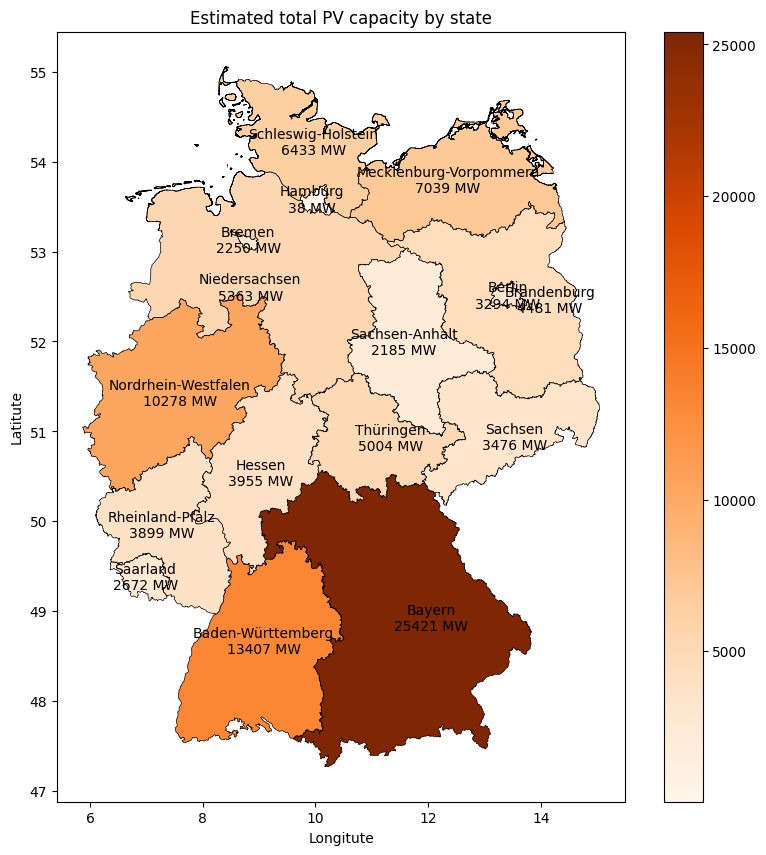

In [31]:

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# Preprocessing
sis = pd_data_solar_energy["SIS"].reset_index()
sis["time"] = pd.to_datetime(sis["time"])
mask_time = (sis["time"] >= start_dates_to_test[0]) & (sis["time"] <= end_date)
sis = sis[mask_time]
sis["time_day"] = sis["time"].dt.floor("D")

# Loading the shape of the states
states = gpd.read_file("https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/master/2_bundeslaender/1_sehr_hoch.geo.json")
states = states.to_crs(epsg=4326)

# Get all grid cells
grid = sis[["lat", "lon"]].drop_duplicates()

# Create a gdf of all the grid cells
grid_gdf = gpd.GeoDataFrame(grid, geometry=gpd.points_from_xy(grid["lon"], grid["lat"]), crs="EPSG:4326")

# Match grid cells and states
grid_and_state = gpd.sjoin(grid_gdf, states[["name", "geometry"]], how="inner", predicate="within")[["lat", "lon", "name"]]

# Conversion back to DF
grid_and_state = pd.DataFrame(grid_and_state)

# Add the states to sis data
sis_and_state = sis.merge(grid_and_state, on=["lat", "lon"], how="inner")

# daily average per state
sis_state_daily_average = sis_and_state.groupby(["time_day", "name"])["SIS"].mean().unstack("name")


# Preprocess the SMARD date on the total PV production in Germany
pv_raw = pd_data_solar_production.copy()
pv_raw["Datum von"] = pd.to_datetime(pv_raw["Datum von"], format="%d.%m.%Y %H:%M")
pv_raw["PV_MWh"] = pv_raw["Photovoltaik [MWh] Berechnete Auflösungen"].astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex=False).replace({"": np.nan, "-": np.nan}).astype(float)

pv_hourly = pv_raw.set_index("Datum von")["PV_MWh"]

# get each year to the same scale
target_year = pd.to_datetime(end_date).year
yearly_sum = pv_hourly.groupby(pv_hourly.index.year).sum()
target_year_sum = yearly_sum.loc[target_year]
scale_factors = target_year_sum / yearly_sum

pv_hourly = pv_hourly * pv_hourly.index.year.map(scale_factors)


# time window + daily sampling
pv_daily_sum = pv_hourly.loc[start_dates_to_test[0]:end_date].resample("D").sum()


common_days_all = sis_state_daily_average.index.intersection(pv_daily_sum.index)
X_df_all = sis_state_daily_average.loc[common_days_all].copy()
y_df_all = pv_daily_sum.loc[common_days_all]

X_all = X_df_all.to_numpy()
y_all = y_df_all.to_numpy()
dates_all = X_df_all.index

kf = KFold(n_splits=5, shuffle=True)

results = []
total_steps = len(start_dates_to_test) * len(alphas_to_test)
current_step = 0

for start_date_hist in start_dates_to_test:
    hist_mask = (dates_all >= start_date_hist) & (dates_all <= "2023-12-31")
    mask_2024 = (dates_all >= "2024-01-01") & (dates_all <= "2024-12-31")

    idx_hist = np.where(hist_mask)[0]
    idx_2024 = np.where(mask_2024)[0]

    for alpha_test in alphas_to_test:
        current_step += 1

        rmse_scores = []

        for train_part, val_part in kf.split(idx_2024):
            train_2024_idx = idx_2024[train_part]
            val_2024_idx   = idx_2024[val_part]

            if len(idx_hist) > 0:
                train_idx = np.concatenate([idx_hist, train_2024_idx])
            else:
                train_idx = train_2024_idx

            X_train = X_all[train_idx]
            y_train = y_all[train_idx]

            X_val = X_all[val_2024_idx]
            y_val = y_all[val_2024_idx]

            model_cv = Ridge(alpha=alpha_test, fit_intercept=True, positive=True, solver="lbfgs")
            model_cv.fit(X_train, y_train)
            y_pred_val = model_cv.predict(X_val)

            rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
            rmse_scores.append(rmse)

        mean_rmse = np.mean(rmse_scores)

        results.append({"start_date": start_date_hist, "alpha": alpha_test, "rmse_mean": mean_rmse})

results_df = pd.DataFrame(results)

best_row = results_df.loc[results_df["rmse_mean"].idxmin()]
best_start_date = best_row["start_date"]
best_alpha = best_row["alpha"]

pivot = results_df.pivot(index="start_date", columns="alpha", values="rmse_mean")

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Alpha")
ax.set_ylabel("Startt date")
ax.set_title("RMSE (using cross validation only on 2024) for alpha and start date")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("RMSE")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        col = "white" if im.norm(val) < 0.5 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8, color=col)

best_i = list(pivot.index).index(best_start_date)
best_j = list(pivot.columns).index(best_alpha)
ax.scatter(best_j, best_i, s=1500, facecolors="none", edgecolors="red", linewidths=2)

plt.tight_layout()
plt.show()


# Linear Regression

mask_final = (dates_all >= best_start_date) & (dates_all <= end_date)
X_df = X_df_all.loc[mask_final].copy()
y_df = y_df_all.loc[mask_final]

# in Arrays
X = X_df.to_numpy()
y = y_df.to_numpy()

model = Ridge(alpha=best_alpha, fit_intercept=True, positive=True, solver="lbfgs")
model.fit(X, y)

weights = model.coef_
states_list = list(X_df.columns)

weights_states = pd.DataFrame({"state": states_list, "weight": weights})

# Calculate the relative proportion of each state
weights_states["rel_proportion"] = weights_states["weight"] / weights_states["weight"].sum()

weights_states["pv_MW_estimated"] = weights_states["rel_proportion"] * total_pv_MW

states_weights = states.merge(weights_states, left_on="name", right_on="state",how="left")


# Plotting

fig, ax = plt.subplots(figsize=(10, 10))

states_weights.plot(ax=ax, column="pv_MW_estimated", cmap="Oranges", legend=True, edgecolor="black", linewidth=0.5)

ax.set_title("Estimated total PV capacity by state")
ax.set_xlabel("Longitute")
ax.set_ylabel("Latitute")

for _, row in states_weights.iterrows():
    x, y = row["geometry"].representative_point().coords[0]
    ax.text(x, y, f'{row["name"]}\n{row["pv_MW_estimated"]:.0f} MW', ha="center", va="center", fontsize=10)

plt.show()


# Checking the accuracy of our estimate #

### Actual distribution of installed PV capacity in Germany (2024) ###

<img src="photovoltaik-leistung-deutschland-karte.webp" width=200>

In [42]:
def compute_errors(states_weights):

    true_pv_MW = {
        "Schleswig-Holstein": 3716,
        "Hamburg":             185,
        "Niedersachsen":      8743,
        "Bremen":              133,
        "Nordrhein-Westfalen":12032,
        "Hessen":             4545,
        "Rheinland-Pfalz":    5084,
        "Saarland":           1023,
        "Baden-Württemberg": 12441,
        "Bayern":            26588,
        "Mecklenburg-Vorpommern": 4246,
        "Sachsen-Anhalt":     4735,
        "Thüringen":          2803,
        "Sachsen":            4605,
        "Brandenburg":        7942,
        "Berlin":              377,
    }

    true_pv_MW = pd.Series(true_pv_MW, name="pv_MW_true")

    states_area = states_weights.to_crs(epsg=3035).copy()
    states_area["area_km2"] = states_area["geometry"].area / 1e6

    comp = states_area.set_index("name").join(true_pv_MW.rename("pv_MW_true"))

    comp["abs_error_MW"] = (comp["pv_MW_estimated"] - comp["pv_MW_true"]).abs()

    comp["ratio_area"] = comp["area_km2"] / comp["area_km2"].sum()

    area_MAE_MW = (comp["ratio_area"] * comp["abs_error_MW"]).sum()


    comp["rel_error_pct"] = comp["abs_error_MW"] / comp["pv_MW_true"] * 100

    comp["abs_pct_error"] = comp["abs_error_MW"] / comp["pv_MW_true"]
    area_PCT = (comp["ratio_area"] * comp["abs_pct_error"]).sum() * 100

    return area_MAE_MW, area_PCT

area_MAE_MW, area_PCT = compute_errors(states_weights)

print(f"Area-weighted average error: {area_PCT} %")

Area-weighted average error: 56.23172506858415 %


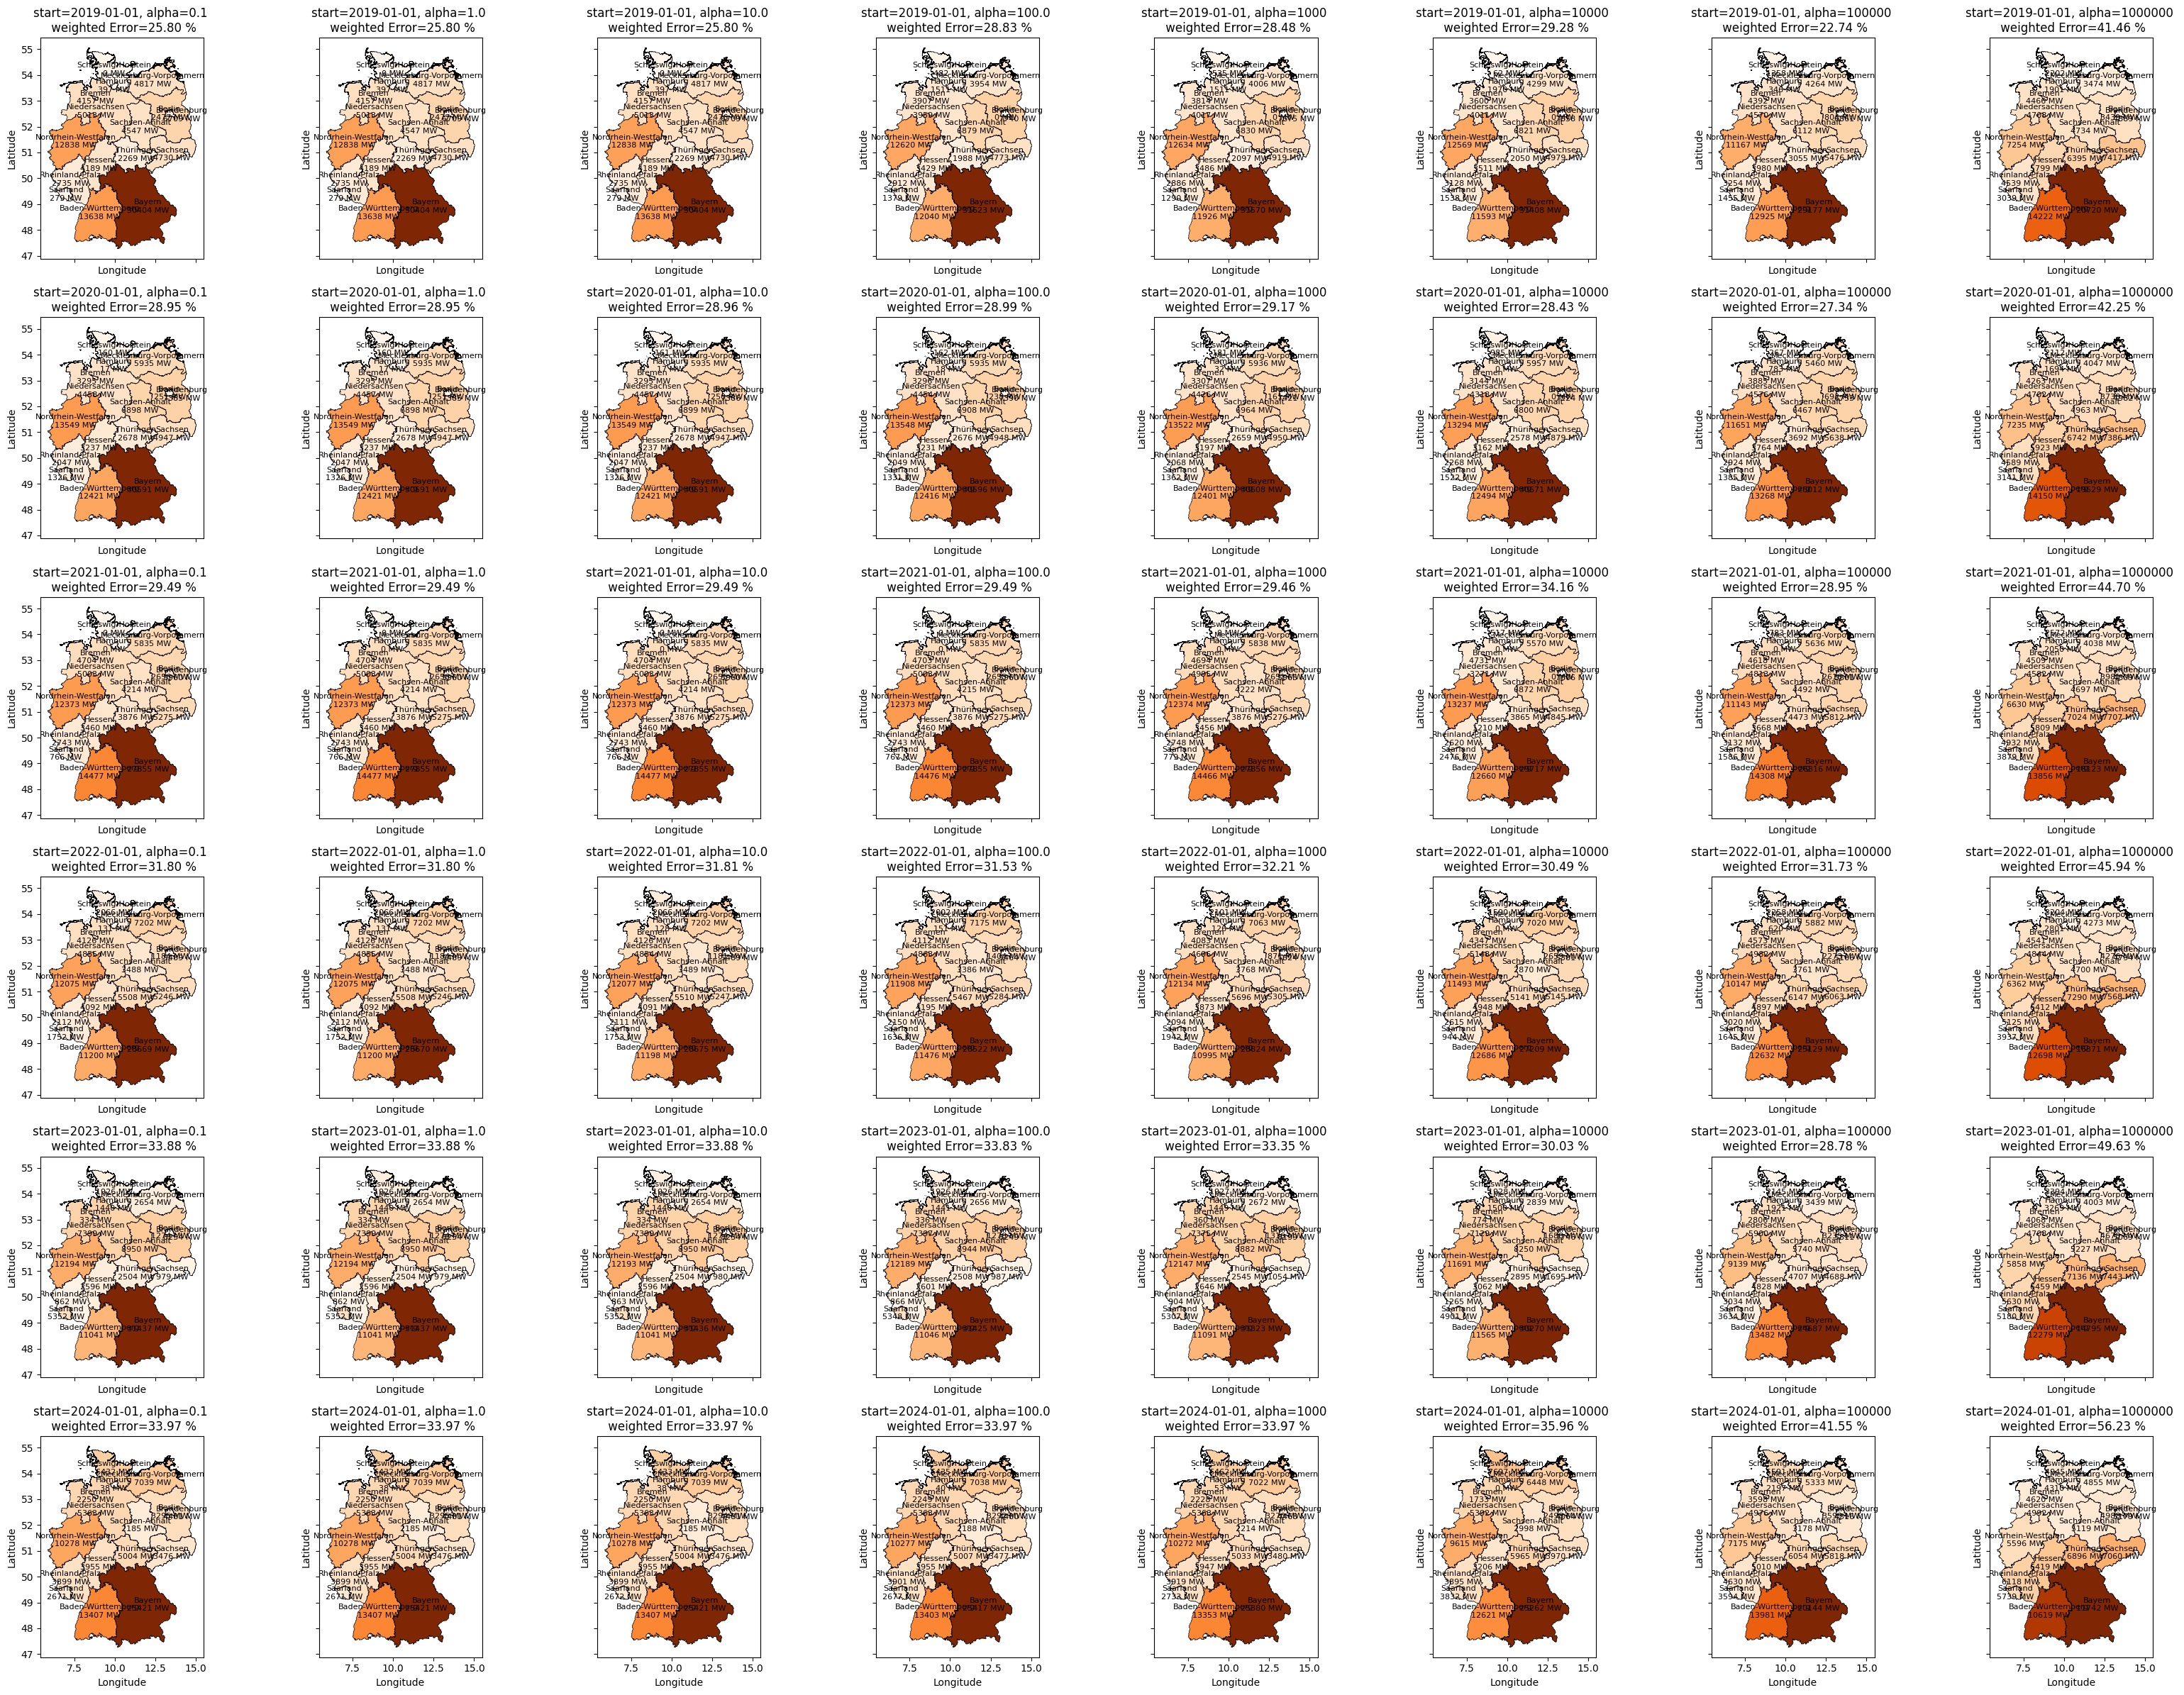

In [43]:
n_rows = len(start_dates_to_test)
n_cols = len(alphas_to_test)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharex=True, sharey=True)

for i, start_date in enumerate(start_dates_to_test):
    mask_final = (dates_all >= start_date) & (dates_all <= end_date)
    X_df = X_df_all.loc[mask_final].copy()
    y_df = y_df_all.loc[mask_final]

    for j, alpha in enumerate(alphas_to_test):
        X = X_df.to_numpy()
        y = y_df.to_numpy()

        model = Ridge(alpha=alpha, fit_intercept=True, positive=True, solver="lbfgs")
        model.fit(X, y)

        weights = model.coef_
        states_list = list(X_df.columns)

        weights_states = pd.DataFrame({"state": states_list, "weight": weights})
        weights_states["rel_proportion"] = weights_states["weight"] / weights_states["weight"].sum()
        weights_states["pv_MW_estimated"] = weights_states["rel_proportion"] * total_pv_MW

        states_weights = states.merge(weights_states, left_on="name", right_on="state", how="left")

        area_MAE_MW, area_PCT = compute_errors(states_weights)

        ax = axes[i, j]
        states_weights.plot(ax=ax, column="pv_MW_estimated", cmap="Oranges", legend=False, edgecolor="black", linewidth=0.5)

        ax.set_title(f"start={start_date}, alpha={alpha} \n weighted Error={area_PCT:.2f} %")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        for _, row in states_weights.iterrows():
            x, y = row["geometry"].representative_point().coords[0]
            ax.text(x, y, f'{row["name"]}\n{row["pv_MW_estimated"]:.0f} MW', ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()